<a href="https://colab.research.google.com/github/imaniiz/CariSurg-Portfolio/blob/main/Week5_Data_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 Assignment AI-Assisted Triage: Data Exploration

In [31]:
# Environment Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Let pandas show more of a wide table when we print it:
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Environment ready · pandas", pd.__version__)

Environment ready · pandas 2.2.2


In [57]:
from pathlib import Path
from google.colab import drive
drive.mount("/content/drive")

CLEAN_PATH = Path("triage_cleaned_v1.csv")
RAW_PATH = Path('/content/drive/MyDrive/Carisurg Portfolio/CariSurg_Week5/yaleemmlc_admissionprediction_triage.csv')

if CLEAN_PATH.exists():
    df = pd.read_csv(CLEAN_PATH); print("Loaded cleaned data from Tutorial 3")
elif RAW_PATH.exists():
    df = clean_triage(pd.read_csv(RAW_PATH, index_col=0)); print("Rebuilt from raw via clean_triage()")
else:
    raise FileNotFoundError("Need triage_cleaned_v1.csv or the raw CSV.")

raw = pd.read_csv(RAW_PATH, index_col=0) if RAW_PATH.exists() else None
fam = classify_columns(df); os.makedirs("figs", exist_ok=True); print(df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rebuilt from raw via clean_triage()
(55121, 225)


## Data Exploration

In [58]:
# Printing the first 5 rows of the data
df.head()

,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,...,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
7,A,4,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,B,2,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,Admit,Walk-in,September,Monday,11-14,Discharge,118.0,105.0,79.0,20.0,98.0,0.0,97.5,113.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,A,2,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,Discharge,ambulance,June,Tuesday,15-18,Admit,76.0,116.0,71.0,18.0,99.0,0.0,98.1,108.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,A,3,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,Discharge,Car,April,Sunday,23-02,Discharge,106.0,103.0,63.0,16.0,97.0,0.0,98.2,85.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,A,2,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,Discharge,ambulance,July,Wednesday,23-02,Discharge,84.0,109.0,68.0,18.0,95.0,0.0,97.8,88.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [59]:
# Printing information on dataset

print("Column types at a glance:")     # Column types
print(df.dtypes.value_counts(), "\n")  # No. of numeric vs text columns

# Separating the dataset into:
# Strctured columns: demographiuc, clinical, administrative and outcome variables
# Chief compliant(cc) flags: binary (0/1) indicators showing whether a patient presented
# with a particular compliant eg. chest pain
structured = [c for c in df.columns if not c.startswith("cc_")]
cc_flags   = [c for c in df.columns if c.startswith("cc_")]

# Printing information on the structured columns of the dataset
df[structured].info()

# Printing the number of chief compliant flags
print(f"\nChief-complaint flags (cc_*): {len(cc_flags)}")

Column types at a glance:
float64    209
object      15
int64        1
Name: count, dtype: int64 

<class 'pandas.core.frame.DataFrame'>
Index: 55121 entries, 7 to 433332
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   dep_name                55121 non-null  object 
 1   esi                     55121 non-null  int64  
 2   age                     55121 non-null  float64
 3   gender                  55121 non-null  object 
 4   ethnicity               55121 non-null  object 
 5   race                    55121 non-null  object 
 6   lang                    55121 non-null  object 
 7   religion                55121 non-null  object 
 8   maritalstatus           55121 non-null  object 
 9   employstatus            55121 non-null  object 
 10  insurance_status        55121 non-null  object 
 11  disposition             55121 non-null  object 
 12  arrivalmode             55121 non-null  object 
 

In [60]:
# Sorting dataset into feature familites

TARGET = "esi"   # Emergency Severity Index: 1 (most urgent), 5 (least)

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

# Who the patient is (fairness-sensitive information)
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]

# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]

# OUTCOMES of the visit - known only AFTER triage
LEAKAGE = ["disposition", "previousdispo"]

def classify_columns(df):
    """Sort the DataFrame's columns into families and return them in a dictionary."""

    # Keeping only the names that really exist in df
    def keep_present(wanted):
        present = []
        for col in wanted:
            if col in df.columns:
                present.append(col)
        return present

    # Sorting the chief compliant's columns by prefix
    chief_complaints = []
    for col in df.columns:
        if col.startswith("cc_"):
            chief_complaints.append(col)

    families = {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }
    return families

In [61]:
# Reference ranges for general adult triage

# Each entry is (low, high, unit).
# NOTE: temperature is in FAHRENHEIT in this dataset (≈98.6 normal), not Celsius!
NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), "triage_glucose": (70,140,"mg/dL")}

# "Plausible" bounds are much wider than normal — anything OUTSIDE these is treated as a
# data error (e.g. a heart rate of 5). Each entry is (low, high).
PLAUSIBLE = {"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_glucose": (20,800)}

In [62]:
import os
def clean_triage(raw):
    """Canonical Week-5 cleaning pipeline (the same steps you build in Tutorial 3).
    Takes the raw DataFrame and returns a cleaned copy."""
    d = raw.copy()
    fam = classify_columns(d)

    # 1. Drop rows with no triage label — we cannot learn a decision the data never recorded.
    d = d[d[TARGET].notna()].copy()

    # 2. Make the vital-sign columns (and age) numeric. Any stray text becomes NaN.
    numeric_cols = list(fam["vitals"])          # a copy of the vital-column list
    if "age" in d.columns:
        numeric_cols.append("age")
    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # 3. Flag physiologically impossible values as missing (NaN) — do not "cap" them.
    for col in PLAUSIBLE:
        low, high = PLAUSIBLE[col]
        if col in d.columns:
            out_of_range = (d[col] < low) | (d[col] > high)
            d.loc[out_of_range, col] = np.nan

    # 4. Fill the gaps. Vitals -> median (a robust middle value).
    for col in fam["vitals"]:
        d[col] = d[col].fillna(d[col].median())
    # A blank oxygen-device flag or chief-complaint flag means "not recorded" = 0.
    if "triage_vital_o2_device" in d.columns:
        d["triage_vital_o2_device"] = d["triage_vital_o2_device"].fillna(0)
    for col in fam["chief_complaints"]:
        d[col] = d[col].fillna(0)
    # Text categories: a blank becomes the explicit category "Unknown".
    for col in fam["demographics"] + fam["admin"] + fam["leakage"]:
        if d[col].dtype == object:
            d[col] = d[col].fillna("Unknown")

    # 5. The target should be a whole number 1-5, not a decimal.
    d[TARGET] = d[TARGET].round().astype(int)
    return d

In [63]:
raw = pd.read_csv(RAW_PATH, index_col=0) if RAW_PATH.exists() else None
fam = classify_columns(df); os.makedirs("figs", exist_ok=True); print(df.shape)

(55121, 225)


## Identifying Missing Data


In [65]:
# Using the .isna function to determine the percentage of missing per structured column,
# worst first, gaps only

# Determining fraction of missing values per column
missing_fraction = df[structured].isna().mean()

# Turning fraction into a percentage and sorting in ascending order
missing_percent = (missing_fraction * 100).round(1)
missing_percent = missing_percent.sort_values(ascending=False)

# Showing only the number columns with gap or missing data
missing_percent[missing_percent > 0]

,0


In [44]:
!pip install missingno -q

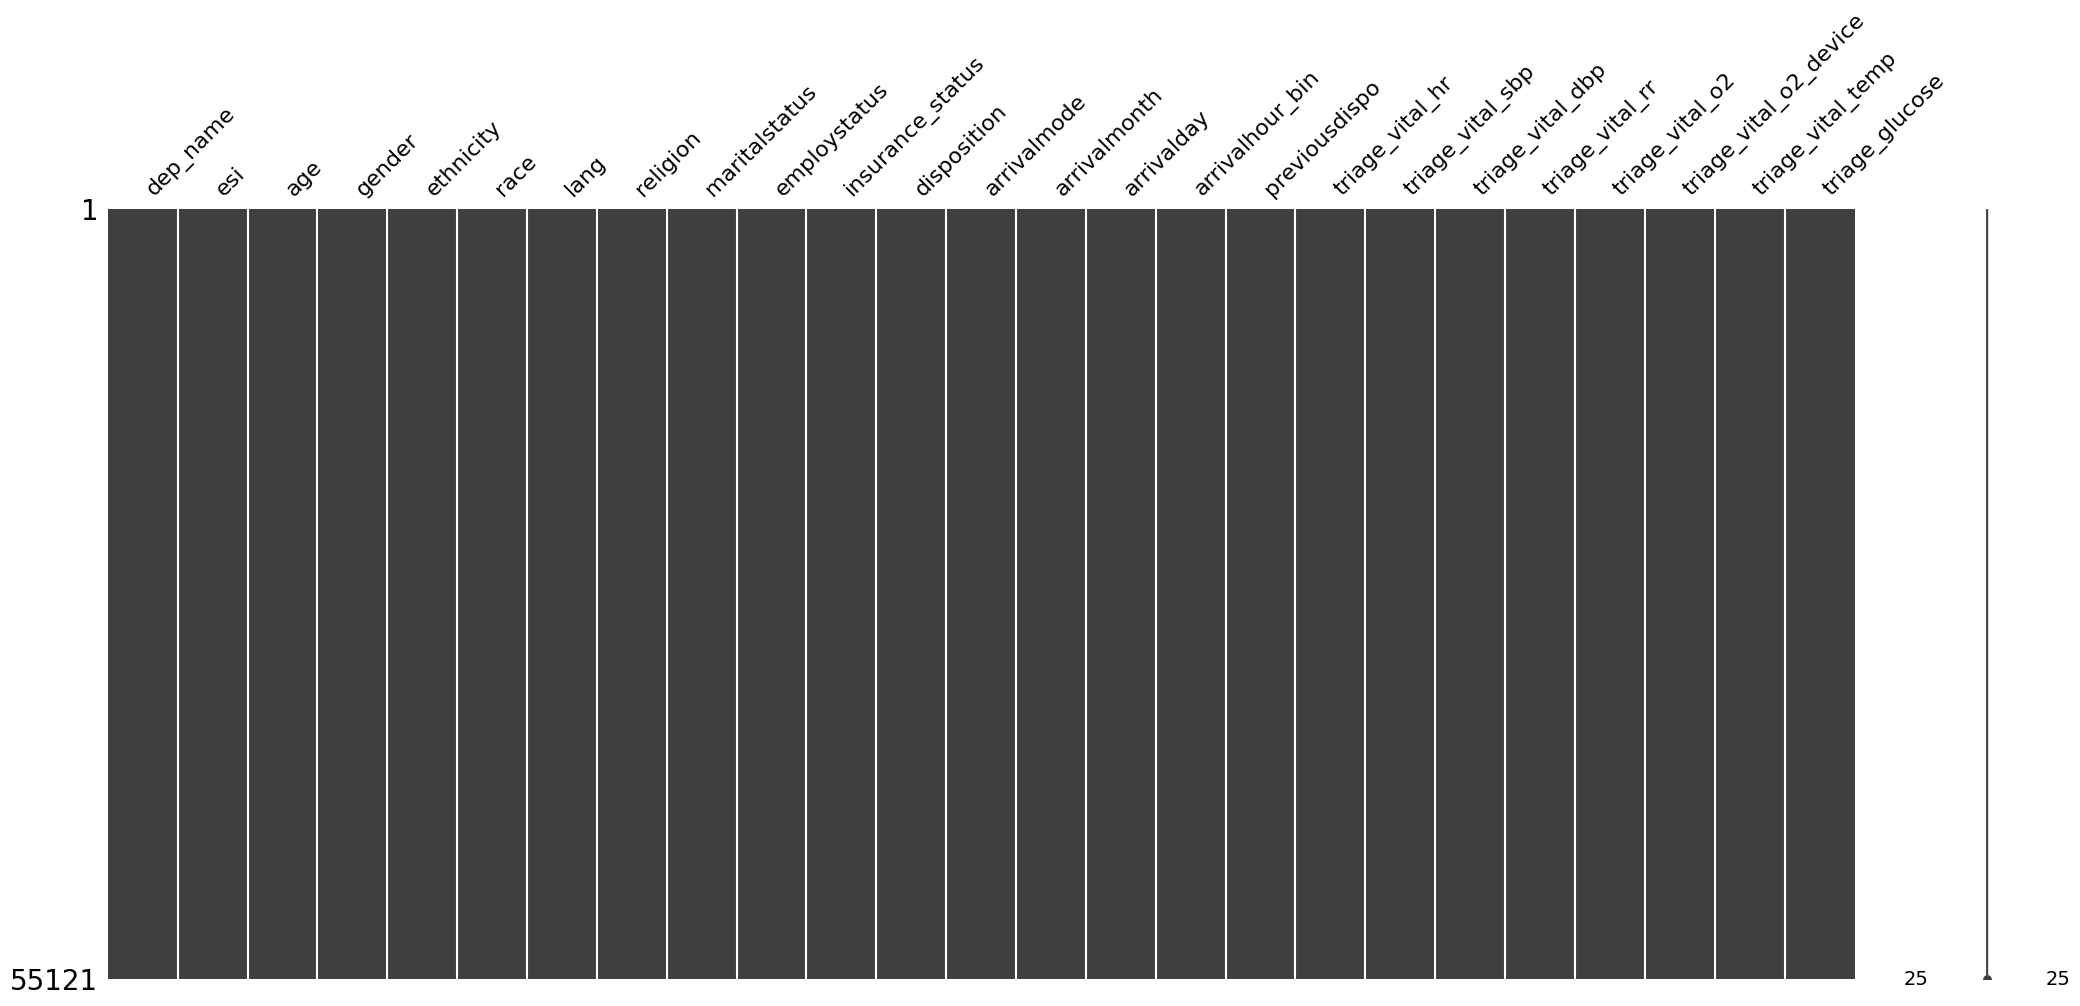

In [66]:
# Missingness map of the structured block (a 226-col map is unreadable)
try:
    import missingno as msno              # Colab: !pip install missingno -q
    msno.matrix(df[structured]); plt.show()
except Exception:
    fig, ax = plt.subplots(figsize=(11,4))
    ax.imshow(df[structured].isna().values, aspect="auto", cmap="gray_r")
    ax.set_xticks(range(len(structured))); ax.set_xticklabels(structured, rotation=90, fontsize=7)
    ax.set_title("Missing cells — structured columns (dark = missing)"); plt.tight_layout(); plt.show()

## Data Type Audit & Distribution

In [67]:
# Data types audit and target sanity
print(df[structured].dtypes)
print("\nESI value counts (raw):"); print(df[TARGET].value_counts(dropna=False).sort_index())

dep_name                   object
esi                         int64
age                       float64
gender                     object
ethnicity                  object
race                       object
lang                       object
religion                   object
maritalstatus              object
employstatus               object
insurance_status           object
disposition                object
arrivalmode                object
arrivalmonth               object
arrivalday                 object
arrivalhour_bin            object
previousdispo              object
triage_vital_hr           float64
triage_vital_sbp          float64
triage_vital_dbp          float64
triage_vital_rr           float64
triage_vital_o2           float64
triage_vital_o2_device    float64
triage_vital_temp         float64
triage_glucose            float64
dtype: object

ESI value counts (raw):
esi
1       77
2    17924
3    27010
4     8896
5     1214
Name: count, dtype: int64


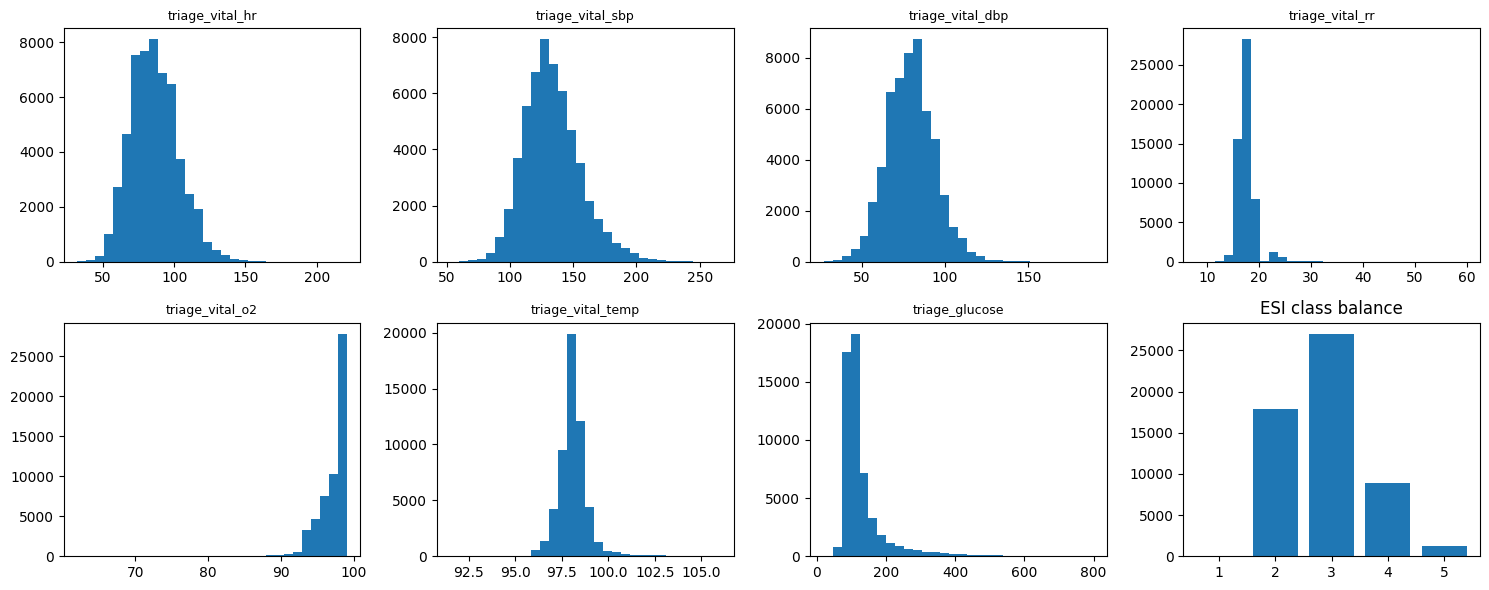

In [68]:
# Draw a histogram for each vital. (The instructor version also adds an ESI bar.)
vitals = fam["vitals"]
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
panels = axes.ravel()           # flatten the 2x4 grid into a list of 8 panels

# Cleaning df[col] by converting to numeric, removing errors and NaNs
for panel, col in zip(panels, vitals):
    values = pd.to_numeric(df[col], errors="coerce").dropna()
    panel.hist(values, bins=30)
    panel.set_title(col, fontsize=9)
    pass

esi_counts = df[TARGET].value_counts().sort_index()
panels[-1].bar(esi_counts.index, esi_counts.values)
panels[-1].set_title("ESI class balance")

plt.tight_layout(); plt.show()

In [69]:
# Demographics
for c in ["race","ethnicity","insurance_status"]:
    print(c, "->", df[c].value_counts(dropna=False).to_dict())

race -> {'White or Caucasian': 29435, 'Black or African American': 15963, 'Other': 9016, 'Patient Refused': 370, 'Asian': 175, 'Unknown': 76, 'American Indian or Alaska Native': 66, 'Native Hawaiian or Other Pacific Islander': 20}
ethnicity -> {'Non-Hispanic': 45142, 'Hispanic or Latino': 9888, 'Patient Refused': 56, 'Unknown': 35}
insurance_status -> {'Medicaid': 21427, 'Medicare': 17581, 'Commercial': 14056, 'Other': 1883, 'Self pay': 174}


In [70]:
# Gender
for c in ["gender"]:
    print(c, "->", df[c].value_counts(dropna=False).to_dict())

gender -> {'Female': 31744, 'Male': 23377}


In [71]:
# Vital signs — quick statistical summary
vitals = [
    "triage_vital_hr",
    "triage_vital_rr",
    "triage_vital_temp",
    "triage_vital_sbp",
    "triage_vital_dbp",
    "triage_vital_o2"
]

df[vitals].describe().T

,count,mean,std,min,25%,50%,75%,max
triage_vital_hr,55121.0,86.447618,16.955556,32.0,74.0,85.0,97.0,221.0
triage_vital_rr,55121.0,17.838753,2.028622,8.0,16.0,18.0,18.0,60.0
triage_vital_temp,55121.0,98.090311,0.813266,91.5,97.7,98.0,98.4,106.0
triage_vital_sbp,55121.0,133.680403,22.645812,53.0,118.0,132.0,147.0,266.0
triage_vital_dbp,55121.0,79.531401,14.594082,27.0,70.0,79.0,89.0,189.0
triage_vital_o2,55121.0,97.021393,2.084465,62.0,96.0,98.0,98.0,99.0


## Detecting Outlies

In [72]:
# Determining outliers
def outlier_report(df, col):
    """Count two kinds of outlier in one numeric column."""
    x = pd.to_numeric(df[col], errors="coerce").dropna()   # numbers only

    # STATISTICAL OUTLIERS (the 1.5 x IQR "fence")
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    low_fence = q1 - 1.5*iqr
    high_fence = q3 + 1.5*iqr
    iqr_outliers = ((x < low_fence) | (x > high_fence)).sum()

    # CLINICALLY IMPOSSIBLE (outside the wide plausible bounds)
    hard_low, hard_high = PLAUSIBLE.get(col, (-np.inf, np.inf))
    impossible = ((x < hard_low) | (x > hard_high)).sum()

    return {"iqr_outliers": iqr_outliers, "impossible": impossible}

report_rows = {}
for col in fam["vitals"]:
    report_rows[col] = outlier_report(df, col)
pd.DataFrame(report_rows).T

,iqr_outliers,impossible
triage_vital_hr,578,0
triage_vital_sbp,1028,0
triage_vital_dbp,726,0
triage_vital_rr,2362,0
triage_vital_o2,1505,0
triage_vital_temp,3554,0
triage_glucose,5648,0


In [73]:
# Making a numeric copy of the vitals so we can correlate them with ESI.
vitals_numeric = df[fam["vitals"]].copy()
for col in fam["vitals"]:
    vitals_numeric[col] = pd.to_numeric(vitals_numeric[col], errors="coerce")

# VITALS vs ESI
vital_corr = vitals_numeric.corrwith(df[TARGET]).sort_values()
print("Vital vs ESI:")
print(vital_corr.round(3))

# CHIEF COMPLAINTS vs ESI (they are already 0/1 numbers)
cc_corr = df[fam["chief_complaints"]].corrwith(df[TARGET]).dropna().sort_values()
print("\n Chief Complaints vs ESI:")
print(cc_corr.head(8).round(3))


Vital vs ESI:
triage_vital_rr     -0.097
triage_vital_hr     -0.095
triage_glucose      -0.078
triage_vital_temp   -0.022
triage_vital_sbp     0.001
triage_vital_dbp     0.046
triage_vital_o2      0.178
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



 Chief Complaints vs ESI:
cc_chestpain               -0.164
cc_shortnessofbreath       -0.150
cc_suicidal                -0.143
cc_alcoholintoxication     -0.142
cc_alteredmentalstatus     -0.132
cc_psychiatricevaluation   -0.103
cc_weakness                -0.081
cc_syncope                 -0.075
dtype: float64


In [74]:
# TODO: one row per measured problem (missing esi, missing vitals, impossible values,
# Fahrenheit, sparse cc_, leakage, representativeness). Columns: issue, columns, action.
issues = [
    {"issue": "Missing ESI label", "columns": "esi", "action": "drop rows w/o target"},
    {"issue": "Missing ESI label", "columns": "esi", "action": "drop rows w/o target"},
    {"issue": "Missing ESI label", "columns": "esi", "action": "drop rows w/o target"}

]
pd.DataFrame(issues)

,issue,columns,action
0,Missing ESI label,esi,drop rows w/o target
1,Missing ESI label,esi,drop rows w/o target
2,Missing ESI label,esi,drop rows w/o target


## Data Visualisation

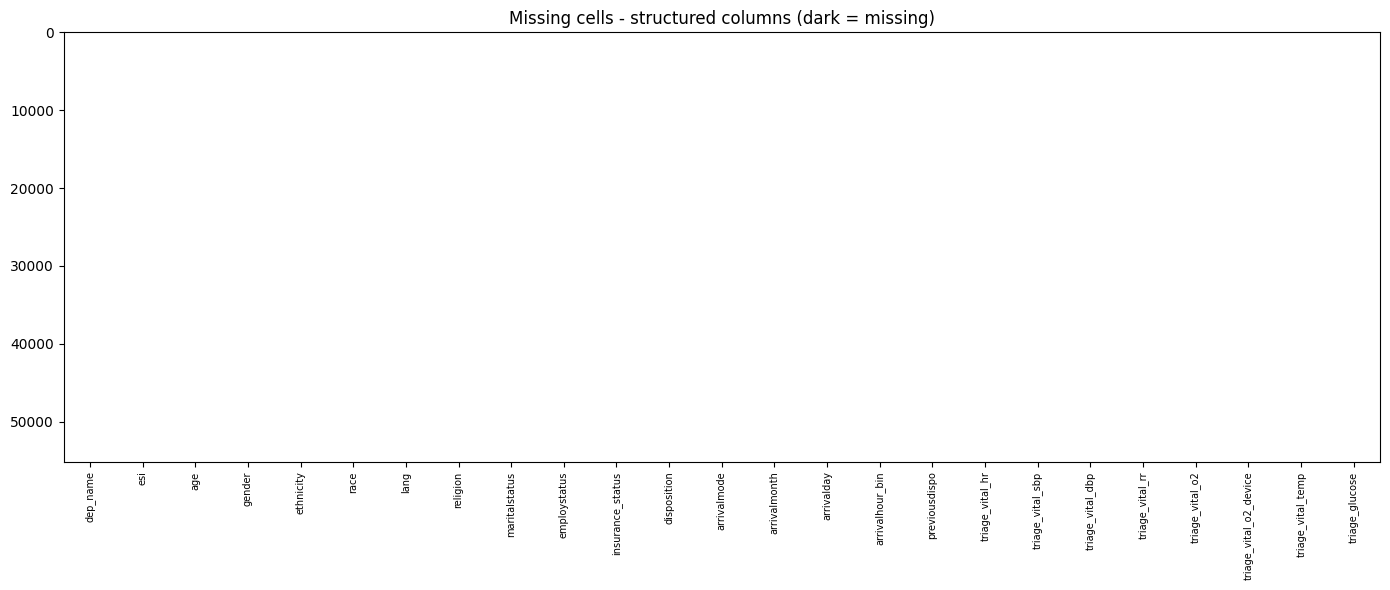

In [77]:
# Plot 1: Missing Cells - Structured Column
src = (raw if raw is not None else df)
structured = [c for c in src.columns if not c.startswith("cc_")]

fig, ax = plt.subplots(figsize =(14,6))
ax.imshow(src[structured].isna().values, aspect ="auto", cmap="gray_r")
ax.set_xticks(range(len(structured)))
ax.set_xticklabels(structured, rotation=90, fontsize=7)
ax.set_title("Missing cells - structured columns (dark = missing)")
plt.tight_layout()
plt.savefig("figs/01_missingness.png", dpi=110)
plt.show()


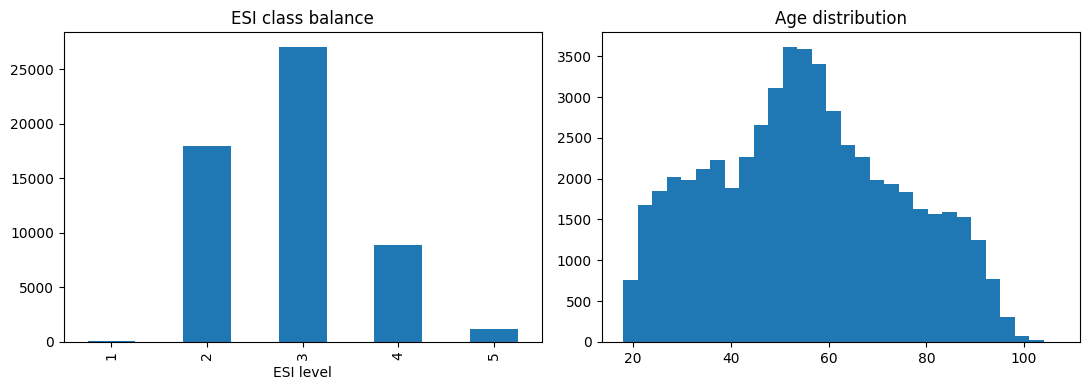

In [78]:
# Plot 2: Age Distribution
fig, ax = plt.subplots(1, 2, figsize=(11,4))

# ESI classes
esi_counts = df[TARGET].value_counts().sort_index()
esi_counts.plot.bar(ax=ax[0])
ax[0].set_title("ESI class balance")
ax[0].set_xlabel("ESI level")

# Age histogram
ax[1].hist(df["age"], bins=30)
ax[1].set_title("Age distribution")

plt.tight_layout(); plt.savefig("figs/02_esi_age.png", dpi=110); plt.show()

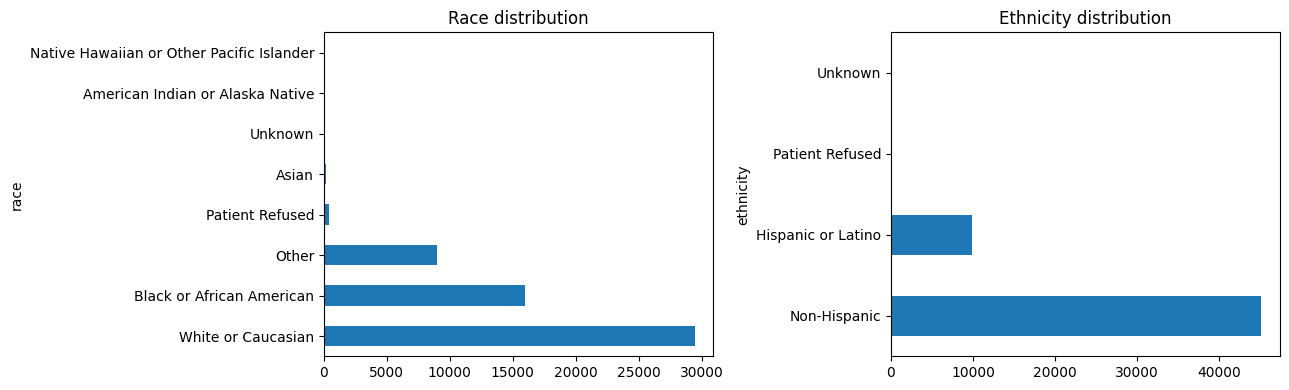

In [79]:
# Plot 3: Ethnicity & Race Distribution

fig, ax = plt.subplots(1, 2, figsize=(13,4))

# Race as a horizontal bar chart
race_counts = df["race"].value_counts()
race_counts.plot.barh(ax=ax[0])
ax[0].set_title("Race distribution")

# Ethnicity as a horizontal bar chart
ethnicity_counts = df["ethnicity"].value_counts()
ethnicity_counts.plot.barh(ax=ax[1])
ax[1].set_title("Ethnicity distribution")
plt.tight_layout(); plt.savefig("figs/03_demographics.png", dpi=110); plt.show()